In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
data.drop_duplicates(inplace=True)
data.dropna(inplace=True)

In [4]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.dropna(inplace=True)

In [5]:
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [6]:
total_customers = len(data)
churn_rate = data['Churn'].mean()
retention_rate = 1 - churn_rate

print("Total Customers:", total_customers)
print("Churn Rate:", churn_rate)
print("Retention Rate:", retention_rate)

Total Customers: 7032
Churn Rate: 0.26578498293515357
Retention Rate: 0.7342150170648465


In [7]:
segmentation = data.groupby(['Contract','PaymentMethod'])['Churn'].mean().reset_index()
print(segmentation.sort_values(by='Churn', ascending=False))

          Contract              PaymentMethod     Churn
2   Month-to-month           Electronic check  0.537297
0   Month-to-month  Bank transfer (automatic)  0.341256
1   Month-to-month    Credit card (automatic)  0.327808
3   Month-to-month               Mailed check  0.315789
6         One year           Electronic check  0.184438
5         One year    Credit card (automatic)  0.103015
4         One year  Bank transfer (automatic)  0.097187
10        Two year           Electronic check  0.077381
7         One year               Mailed check  0.068452
8         Two year  Bank transfer (automatic)  0.033808
9         Two year    Credit card (automatic)  0.022414
11        Two year               Mailed check  0.008000


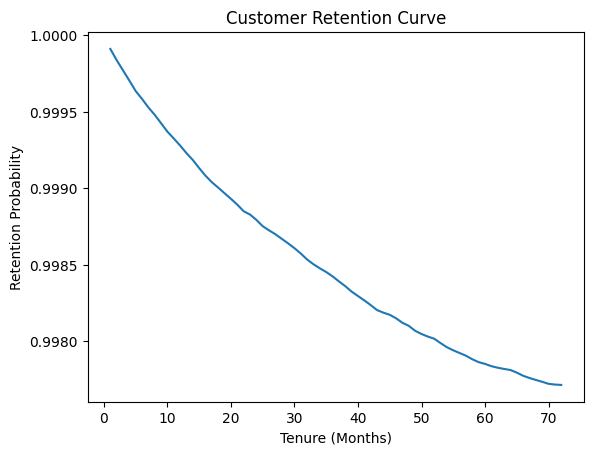

In [8]:
tenure_retention = data.groupby('tenure')['Churn'].mean()
retention_curve = 1 - tenure_retention.cumsum()/len(data)

plt.figure()
plt.plot(retention_curve)
plt.title("Customer Retention Curve")
plt.xlabel("Tenure (Months)")
plt.ylabel("Retention Probability")
plt.show()

In [9]:
data = data.sort_values(by='tenure')

data['SignupMonth'] = pd.to_datetime('2024-01-01') - pd.to_timedelta(data['tenure']*30, unit='D')
data['SignupMonth'] = data['SignupMonth'].dt.to_period('M')

data['CohortIndex'] = data['tenure']


cohort = data.groupby(['SignupMonth','CohortIndex'])['customerID'].count().reset_index()


cohort_pivot = cohort.pivot(index='SignupMonth', columns='CohortIndex', values='customerID')


cohort_size = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

retention_matrix = retention_matrix.astype(float).fillna(0)

print("\nCohort Retention Matrix:")
print(retention_matrix.head())


Cohort Retention Matrix:
CohortIndex   1    2    3    4    5    6    7    8    9    10  ...   63   64  \
SignupMonth                                                    ...             
2018-02      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2018-03      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2018-04      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2018-05      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2018-06      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   

CohortIndex   65   66   67   68   69   70   71   72  
SignupMonth                                          
2018-02      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2018-03      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2018-04      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2018-05      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2018-06      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 72 columns]


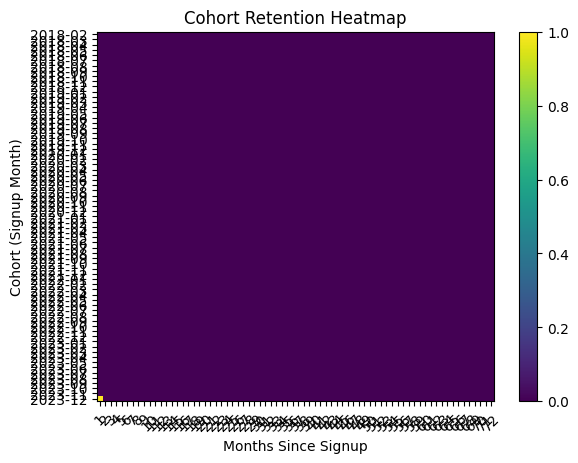

In [10]:
plt.figure()
plt.imshow(retention_matrix, aspect='auto')
plt.title("Cohort Retention Heatmap")
plt.xlabel("Months Since Signup")
plt.ylabel("Cohort (Signup Month)")
plt.colorbar()
plt.xticks(range(len(retention_matrix.columns)), retention_matrix.columns, rotation=45)
plt.yticks(range(len(retention_matrix.index)), retention_matrix.index.astype(str))

plt.show()


In [11]:
avg_lifetime = data['tenure'].mean()

avg_revenue = data['MonthlyCharges'].mean()


ltv = avg_lifetime * avg_revenue

print("Average Lifetime (months):", avg_lifetime)
print("Average Monthly Revenue:", avg_revenue)
print("Customer Lifetime Value (LTV):", ltv)

Average Lifetime (months): 32.421786120591584
Average Monthly Revenue: 64.79820819112628
Customer Lifetime Value (LTV): 2100.8736469702617


In [12]:
segment_ltv = data.groupby('Contract').agg({
    'tenure':'mean',
    'MonthlyCharges':'mean'
})

segment_ltv['LTV'] = segment_ltv['tenure'] * segment_ltv['MonthlyCharges']
print(segment_ltv)

                   tenure  MonthlyCharges          LTV
Contract                                              
Month-to-month  18.036645       66.398490  1197.606009
One year        42.073370       65.079416  2738.110310
Two year        57.071810       60.872374  3474.096562


In [13]:
features = ['tenure','MonthlyCharges','TotalCharges']
correlation = data[features + ['Churn']].corr()

print(correlation['Churn'].sort_values(ascending=False))

Churn             1.000000
MonthlyCharges    0.192858
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64


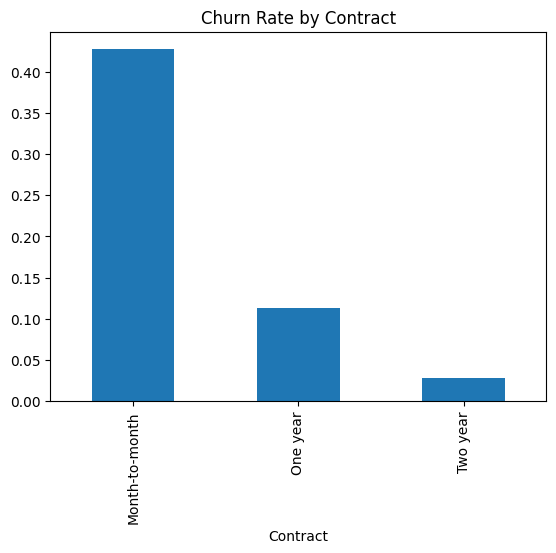

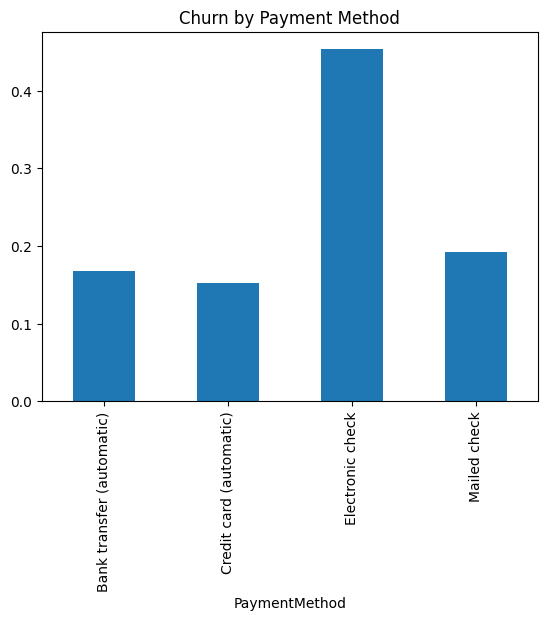

In [17]:

data.groupby('Contract')['Churn'].mean().plot(kind='bar')
plt.title("Churn Rate by Contract")
plt.show()

data.groupby('PaymentMethod')['Churn'].mean().plot(kind='bar')
plt.title("Churn by Payment Method")
plt.show()

/tmp/ipykernel_19283/4036185675.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('TenureGroup')['Churn'].mean().plot(kind='bar')


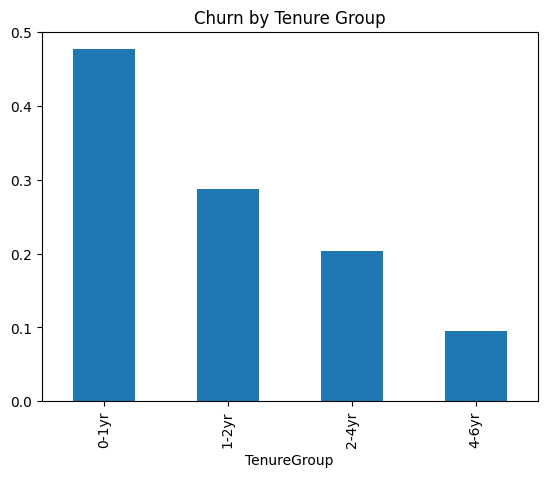

In [18]:
data['TenureGroup'] = pd.cut(data['tenure'],
                            bins=[0,12,24,48,72],
                            labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

data.groupby('TenureGroup')['Churn'].mean().plot(kind='bar')
plt.title("Churn by Tenure Group")
plt.show()

In [14]:
high_risk = data[
    (data['Contract']=='Month-to-month') &
    (data['tenure'] < 12) &
    (data['MonthlyCharges'] > data['MonthlyCharges'].median())
]

print("High Risk Customers:", len(high_risk))

High Risk Customers: 770


In [15]:
print("\nKey Insights:")

if churn_rate > 0.25:
    print("- High churn rate detected")

print("- Early tenure customers churn more")
print("- Month-to-month contracts have highest churn")
print("- High charges increase churn probability")
print("- Long-term customers are stable")


Key Insights:
- High churn rate detected
- Early tenure customers churn more
- Month-to-month contracts have highest churn
- High charges increase churn probability
- Long-term customers are stable


In [16]:
print("\nRecommendations:")

print("- Improve onboarding for first 3 months")
print("- Offer discounts for yearly plans")
print("- Promote auto-payment methods")
print("- Target high-risk users with retention campaigns")


Recommendations:
- Improve onboarding for first 3 months
- Offer discounts for yearly plans
- Promote auto-payment methods
- Target high-risk users with retention campaigns
